# 📊 TD1 — Analyse des données plantaires
**Objectif :** Découvrir, explorer et visualiser les données de semelles instrumentées avant d'entraîner un modèle de reconnaissance d'actions.

---

## 🗺️ Plan du notebook
1. Installation et imports
2. Chargement des données
3. Exploration et compréhension des données
4. Alignement des signaux avec les annotations temporelles
5. Comparaison entre classes d'action
6. Comparaison entre sujets
7. Visualisation : carte de pression plantaire (heatmap)
8. Visualisation : courbes IMU (accélérations et vitesses angulaires)
9. Visualisation : trajectoire du centre de pression
10. Conclusions et pistes pour le prochain TD

---
> 💡 **Comment lire ce notebook :** Les cellules grises contiennent du code Python. Les cellules blanches comme celle-ci contiennent des explications. Exécute chaque cellule dans l'ordre avec `Shift+Entrée`.

## 1. 📦 Installation et imports

On commence par installer les bibliothèques nécessaires si elles ne le sont pas déjà, puis on les importe.

| Bibliothèque | Rôle |
|---|---|
| `pandas` | Manipuler des tableaux de données (comme Excel mais en Python) |
| `numpy` | Calculs mathématiques sur des tableaux de nombres |
| `matplotlib` | Tracer des graphiques |
| `seaborn` | Graphiques statistiques plus jolis, basés sur matplotlib |

In [3]:
# Si une bibliothèque n'est pas installée, décommente la ligne correspondante et exécute cette cellule
# !pip install pandas numpy matplotlib seaborn

import pandas as pd       # Pour les tableaux de données
import numpy as np        # Pour les calculs numériques
import matplotlib.pyplot as plt  # Pour tracer des graphiques
import matplotlib.patches as mpatches
import seaborn as sns     # Pour des graphiques statistiques
import warnings
warnings.filterwarnings('ignore')  # On cache les avertissements non essentiels

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 5)  # Taille par défaut des graphiques

print('✅ Bibliothèques importées avec succès !')

✅ Bibliothèques importées avec succès !


## 2. 📂 Chargement des données

On a deux fichiers CSV dans le dossier `outputs/` :

- **`insoles.csv`** : les mesures des semelles instrumentées (capteurs de pression, IMU, force, centre de pression), à 100 Hz — soit 100 lignes par seconde.
- **`classif.csv`** : les annotations — pour chaque sujet et chaque séquence, on sait *quelle action* se passe entre *quelles secondes*.

### 🔑 Qu'est-ce qu'un CSV ?
Un fichier `.csv` (Comma-Separated Values) est un simple fichier texte où chaque ligne est une observation, et les colonnes sont séparées par des virgules. `pandas.read_csv()` le transforme en **DataFrame** — un tableau manipulable en Python.

In [4]:
# --- Chargement des semelles ---
# pd.read_csv() lit le fichier et retourne un DataFrame (tableau 2D)
# low_memory=False évite des avertissements sur les colonnes avec des types mixtes
insoles = pd.read_csv('outputs/insoles.csv', low_memory=False)

# --- Chargement des annotations ---
classif = pd.read_csv('outputs/classif.csv', low_memory=False)

print(f'insoles : {insoles.shape[0]:,} lignes × {insoles.shape[1]} colonnes')
print(f'classif : {classif.shape[0]:,} lignes × {classif.shape[1]} colonnes')
print('\n✅ Fichiers chargés !')

insoles : 4,844,817 lignes × 54 colonnes
classif : 10,204 lignes × 9 colonnes

✅ Fichiers chargés !


## 3. 🔍 Exploration et compréhension des données

Avant de faire quoi que ce soit, il faut **comprendre ce qu'on a**. On va :
1. Regarder les premières lignes (`.head()`)
2. Vérifier les types de colonnes (`.dtypes`)
3. Obtenir des statistiques de base (`.describe()`)
4. Chercher des valeurs manquantes

In [5]:
# .head(5) affiche les 5 premières lignes
# Utilise la barre de défilement horizontale pour voir toutes les colonnes
print('=== Premières lignes de insoles.csv ===')
insoles.head(5)

=== Premières lignes de insoles.csv ===


,dataset,sequence,subject,Time,left pressure 1[N/cm²],left pressure 2[N/cm²],left pressure 3[N/cm²],left pressure 4[N/cm²],left pressure 5[N/cm²],left pressure 6[N/cm²],...,right pressure 16[N/cm²],right acceleration X[g],right acceleration Y[g],right acceleration Z[g],right angular X[dps],right angular Y[dps],right angular Z[dps],right total force[N],right center of pressure X[-0.5...+0.5],right center of pressure Y[-0.5...+0.5]
0,Plantar_activity,Sequence_01,S01,0.00,4.25,1.75,4.00,2.25,2.75,3.5,...,0.50,-0.232422,0.037109,0.977051,-1.89,-1.19,0.70,542.0,-0.200511,-0.154638
1,Plantar_activity,Sequence_01,S01,0.01,4.25,1.75,4.00,2.25,2.75,3.5,...,0.50,-0.232422,0.037109,0.977051,-1.89,-1.19,0.70,542.0,-0.200511,-0.154638
2,Plantar_activity,Sequence_01,S01,0.02,3.75,1.75,4.00,2.25,2.75,3.5,...,0.50,-0.232422,0.037109,0.977051,-1.89,-1.19,0.70,542.0,-0.200511,-0.154638
3,Plantar_activity,Sequence_01,S01,0.03,3.75,1.75,3.25,2.00,3.00,3.5,...,0.50,-0.229492,0.040527,0.979004,-1.82,-1.05,0.56,544.0,-0.201996,-0.152734
4,Plantar_activity,Sequence_01,S01,0.04,4.25,1.75,4.00,2.00,3.00,3.5,...,0.25,-0.232910,0.039551,0.978516,-2.03,-0.98,0.42,539.0,-0.207568,-0.145954


In [6]:
print('=== Premières lignes de classif.csv ===')
classif.head(10)

=== Premières lignes de classif.csv ===


,dataset,sequence,subject,Name,Class,Frame Start,Timestamp Start,Frame End,Timestamp End
0,Events,Sequence_01,S01,Standing in T-pose,1.0,984.0,8.19167,1572.0,13.09167
1,Events,Sequence_01,S01,Standing on heels,7.0,1572.0,13.09167,2022.0,16.84167
2,Events,Sequence_01,S01,Walking backwards,10.0,2022.0,16.84167,2595.0,21.61667
3,Events,Sequence_01,S01,Climbing the stairs,21.0,2595.0,21.61667,3072.0,25.59167
4,Events,Sequence_01,S01,Standing on tiptoes,6.0,3072.0,25.59167,3666.0,30.54167
5,Events,Sequence_01,S01,Jumping backward,19.0,3666.0,30.54167,4068.0,33.89167
6,Events,Sequence_01,S01,Leaning backward,27.0,4068.0,33.89167,4466.0,37.20833
7,Events,Sequence_01,S01,Walking on tiptoes,11.0,4466.0,37.20833,5504.0,45.85833
8,Events,Sequence_01,S01,Pulling the bag,24.0,5504.0,45.85833,6127.0,51.05000
9,Events,Sequence_01,S01,Balancing on the left leg,3.0,6127.0,51.05000,6477.0,53.96667


In [7]:
# .dtypes indique le type de chaque colonne :
# - object  = texte
# - float64 = nombre décimal
# - int64   = nombre entier
print('=== Types des colonnes de insoles.csv ===')
print(insoles.dtypes)
print('\n=== Types des colonnes de classif.csv ===')
print(classif.dtypes)

=== Types des colonnes de insoles.csv ===
dataset                                        str
sequence                                       str
subject                                        str
Time                                       float64
left pressure 1[N/cm²]                     float64
left pressure 2[N/cm²]                     float64
left pressure 3[N/cm²]                     float64
left pressure 4[N/cm²]                     float64
left pressure 5[N/cm²]                     float64
left pressure 6[N/cm²]                     float64
left pressure 7[N/cm²]                     float64
left pressure 8[N/cm²]                     float64
left pressure 9[N/cm²]                     float64
left pressure 10[N/cm²]                    float64
left pressure 11[N/cm²]                    float64
left pressure 12[N/cm²]                    float64
left pressure 13[N/cm²]                    float64
left pressure 14[N/cm²]                    float64
left pressure 15[N/cm²]                 

In [8]:
# .describe() calcule des statistiques sur chaque colonne numérique :
# count (nombre de valeurs), mean (moyenne), std (écart-type), min, max, percentiles
print('=== Statistiques descriptives de insoles.csv (colonnes numériques) ===')
insoles.describe().T  # .T pour transposer (les colonnes deviennent des lignes)

=== Statistiques descriptives de insoles.csv (colonnes numériques) ===


,count,mean,std,min,25%,50%,75%,max
Time,4844817.0,74.472974,43.035787,0.000000,37.220000,74.440000,111.670000,172.390000
left pressure 1[N/cm²],4829990.0,5.240779,11.107334,-13.942635,0.000000,2.500000,7.000000,525.000000
left pressure 2[N/cm²],4832384.0,4.887774,12.713617,-15.571308,0.000000,1.750000,5.750000,590.000000
left pressure 3[N/cm²],4828819.0,2.982480,6.058687,-9.991312,0.000000,1.500000,4.250000,345.000000
left pressure 4[N/cm²],4829594.0,3.137169,6.381130,-15.126059,0.000000,1.500000,4.750000,725.000000
left pressure 5[N/cm²],4834220.0,0.875635,2.241075,-2.650967,0.000000,0.000000,1.000000,277.500000
left pressure 6[N/cm²],4824217.0,2.015253,5.766591,-7.642462,0.000000,0.250000,2.000000,497.500000
left pressure 7[N/cm²],4829662.0,0.388683,1.988631,-3.321383,0.000000,0.000000,0.250000,562.500000
left pressure 8[N/cm²],4831462.0,1.830777,5.725967,-2.296730,0.000000,0.500000,1.750000,650.000000
left pressure 9[N/cm²],4827890.0,3.101098,9.221896,-14.097116,0.000000,0.750000,3.750000,1525.000000


In [9]:
# Valeurs manquantes : .isna() crée un tableau de True/False
# .sum() compte les True (= les valeurs manquantes) par colonne
missing = insoles.isna().sum()
missing_nonzero = missing[missing > 0]  # On garde seulement les colonnes avec des manquants

total = len(insoles)
print(f'Valeurs manquantes dans insoles.csv (sur {total:,} lignes) :')
for col, count in missing_nonzero.items():
    pct = 100 * count / total
    print(f'  {col}: {count:,} manquantes ({pct:.1f}%)')

if missing_nonzero.empty:
    print('  Aucune valeur manquante ! 🎉')

Valeurs manquantes dans insoles.csv (sur 4,844,817 lignes) :
  left pressure 1[N/cm²]: 14,827 manquantes (0.3%)
  left pressure 2[N/cm²]: 12,433 manquantes (0.3%)
  left pressure 3[N/cm²]: 15,998 manquantes (0.3%)
  left pressure 4[N/cm²]: 15,223 manquantes (0.3%)
  left pressure 5[N/cm²]: 10,597 manquantes (0.2%)
  left pressure 6[N/cm²]: 20,600 manquantes (0.4%)
  left pressure 7[N/cm²]: 15,155 manquantes (0.3%)
  left pressure 8[N/cm²]: 13,355 manquantes (0.3%)
  left pressure 9[N/cm²]: 16,927 manquantes (0.3%)
  left pressure 10[N/cm²]: 11,783 manquantes (0.2%)
  left pressure 11[N/cm²]: 12,413 manquantes (0.3%)
  left pressure 12[N/cm²]: 12,764 manquantes (0.3%)
  left pressure 13[N/cm²]: 13,502 manquantes (0.3%)
  left pressure 14[N/cm²]: 12,480 manquantes (0.3%)
  left pressure 15[N/cm²]: 13,610 manquantes (0.3%)
  left pressure 16[N/cm²]: 12,411 manquantes (0.3%)
  left acceleration X[g]: 10,271 manquantes (0.2%)
  left acceleration Y[g]: 13,905 manquantes (0.3%)
  left acceler

In [10]:
# Quelles actions existent dans le dataset ?
# .value_counts() compte les occurrences de chaque valeur unique
print('Actions disponibles dans classif.csv :')
action_counts = classif['Name'].value_counts()
print(action_counts.to_string())
print(f'\n→ {len(action_counts)} actions différentes au total')
print(f'→ {classif["subject"].nunique()} sujets différents')
print(f'→ {classif["sequence"].nunique()} séquences différentes')

Actions disponibles dans classif.csv :
Name
Standing in T-pose                  638
Pulling the bag                     328
Hopping around on one leg           325
Walking                             323
Jumping on the left leg             323
Leaning forward                     323
Standing on tiptoes                 322
Lifting the bag with two hands      321
Doing squats                        320
Putting left hand on the ground     320
Jumping to the side                 320
Walking backwards                   319
Climbing the stairs                 319
Walking on tiptoes                  319
Side-stepping                       319
Jogging                             319
Sitting on the stool                319
Leaning backward                    318
Looking backward                    318
Lifting the bag with one hand       318
Standing upright without moving     318
Putting right hand on the ground    318
Jumping forward                     317
Jumping in place                    

## 4. 🔗 Alignement des signaux avec les annotations

**Le problème :** `insoles.csv` contient les mesures *brutes* à 100 Hz. Mais on ne sait pas quelle action le sujet est en train de faire à chaque instant.

**La solution :** `classif.csv` nous donne, pour chaque action, son `Timestamp Start` et `Timestamp End`. On va donc **étiqueter** chaque ligne d'`insoles` avec le nom de l'action qui correspond à cet instant.

### 🎯 Stratégie
Pour chaque groupe `(subject, sequence)` :
1. On prend les annotations correspondantes dans `classif`
2. Pour chaque ligne d'`insoles`, on cherche quelle action chevauche le timestamp `Time`
3. On ajoute les colonnes `action_name` et `action_class`

> ⏳ Cette cellule peut prendre quelques secondes car elle traite beaucoup de données.

In [13]:
# ─── VERSION RAPIDE de l'alignement (corrigée) ────────────────────────────

# Étape 1 : convertir les colonnes temporelles
classif['Timestamp Start'] = pd.to_numeric(classif['Timestamp Start'], errors='coerce')
classif['Timestamp End']   = pd.to_numeric(classif['Timestamp End'],   errors='coerce')
insoles['Time']            = pd.to_numeric(insoles['Time'],            errors='coerce')

# Étape 2 : grouper classif par (subject, sequence) pour accès rapide
classif_grouped = classif.groupby(['subject', 'sequence'])

# Étape 3 : traiter chaque groupe (subject, sequence) indépendamment
# merge_asof est appelé sur des petits DataFrames déjà triés → pas de problème de tri global
results = []

for (subject, sequence), insoles_grp in insoles.groupby(['subject', 'sequence']):

    # Trier ce groupe par Time (obligatoire pour merge_asof)
    insoles_grp = insoles_grp.sort_values('Time')

    if (subject, sequence) not in classif_grouped.groups:
        # Pas d'annotation pour ce groupe → on marque "Non annoté"
        insoles_grp['action_name']  = 'Non annoté'
        insoles_grp['action_class'] = -1
        results.append(insoles_grp)
        continue

    # Trier les annotations de ce groupe par Timestamp Start
    annots = classif_grouped.get_group((subject, sequence)).sort_values('Timestamp Start')

    # merge_asof sur ce seul groupe : Time est garanti croissant ici
    merged_grp = pd.merge_asof(
        insoles_grp,
        annots[['Timestamp Start', 'Timestamp End', 'Name', 'Class']],
        left_on='Time',
        right_on='Timestamp Start',
        direction='backward'   # prend l'annotation la plus récente ≤ Time
    )

    # Invalider les lignes où Time dépasse la fin de l'action
    valid = merged_grp['Time'] <= merged_grp['Timestamp End']
    merged_grp['action_name']  = merged_grp['Name'].where(valid, 'Non annoté').fillna('Non annoté')
    merged_grp['action_class'] = merged_grp['Class'].where(valid, -1).fillna(-1)

    # Supprimer les colonnes temporaires
    merged_grp = merged_grp.drop(columns=['Name', 'Class', 'Timestamp Start', 'Timestamp End'])
    results.append(merged_grp)

# Étape 4 : recombiner tous les groupes
insoles = pd.concat(results, ignore_index=True)

print('✅ Alignement terminé !')
print('Répartition des actions :')
print(insoles['action_name'].value_counts().head(15))

✅ Alignement terminé !
Répartition des actions :
action_name
Standing in T-pose                  231163
Walking backwards                   206766
Walking on tiptoes                  200605
Walking                             198526
Hopping around on one leg           192749
Sitting on the stool                189725
Side-stepping                       183459
Jogging                             182572
Lifting the bag with two hands      164531
Lifting the bag with one hand       162460
Putting right hand on the ground    150216
Pulling the bag                     150135
Balancing on the right leg          147475
Putting left hand on the ground     146399
Leaning forward                     145758
Name: count, dtype: int64


## 5. 📊 Comparaison entre classes d'action

Maintenant qu'on a l'étiquette de l'action pour chaque ligne, on peut **comparer les caractéristiques selon l'action**.

On va regarder :
- 💪 La **force totale** exercée sur chaque pied (en Newtons)
- 📈 La distribution de quelques capteurs de pression

### 🎯 Outil clé : le boxplot
Un **boxplot** (boîte à moustaches) montre pour chaque groupe :
- La **boîte** : de Q1 (25%) à Q3 (75%) → là où se trouvent 50% des données
- La **ligne centrale** : la médiane (Q2, 50%)
- Les **moustaches** : Q1 − 1.5×IQR et Q3 + 1.5×IQR
- Les **points** au-delà : valeurs aberrantes (outliers)

In [14]:
# On filtre uniquement les lignes annotées (on exclut 'Non annoté')
df_annotated = insoles[insoles['action_name'] != 'Non annoté'].copy()

# Statistiques moyennes par classe d'action sur la force totale
stats_by_action = df_annotated.groupby('action_name')[[
    'left total force[N]',
    'right total force[N]'
]].agg(['mean', 'std']).round(2)

print('=== Force totale moyenne par action (en Newtons) ===')
print(stats_by_action.to_string())

=== Force totale moyenne par action (en Newtons) ===
                                 left total force[N]         right total force[N]        
                                                mean     std                 mean     std
action_name                                                                              
Balancing on the left leg                     667.38  411.91               141.56  255.45
Balancing on the right leg                    181.75  284.53               609.23  385.40
Climbing the stairs                           390.77  407.16               372.54  400.92
Doing squats                                  378.48  251.61               369.44  257.79
Hopping around on one leg                     371.39  591.31               416.28  593.95
Jogging                                       403.10  497.63               387.75  492.19
Jumping backward                              389.10  342.83               380.93  345.18
Jumping forward                               3

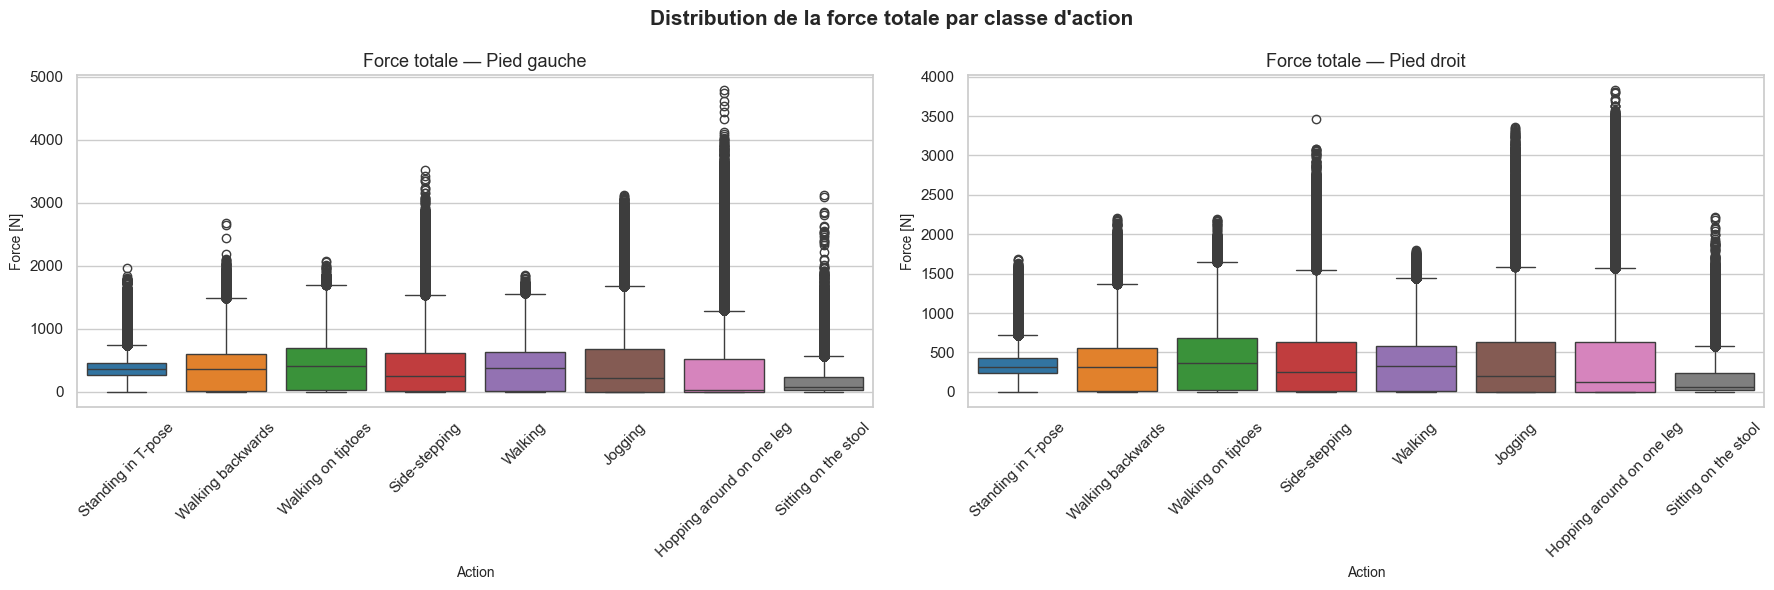

💡 Observations à noter dans le notebook :
  - Quelles actions ont la force la plus élevée ?
  - Y a-t-il des actions asymétriques gauche/droite ?


In [15]:
# On sélectionne les 8 actions les plus représentées pour la lisibilité
top_actions = df_annotated['action_name'].value_counts().head(8).index
df_top = df_annotated[df_annotated['action_name'].isin(top_actions)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, col, label in zip(
    axes,
    ['left total force[N]', 'right total force[N]'],
    ['Pied gauche', 'Pied droit']
):
    sns.boxplot(
        data=df_top,
        x='action_name',   # Une boîte par action
        y=col,             # Valeur représentée
        ax=ax,
        palette='tab10'
    )
    ax.set_title(f'Force totale — {label}', fontsize=13)
    ax.set_xlabel('Action', fontsize=10)
    ax.set_ylabel('Force [N]', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Distribution de la force totale par classe d\'action', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Observations à noter dans le notebook :')
print('  - Quelles actions ont la force la plus élevée ?')
print('  - Y a-t-il des actions asymétriques gauche/droite ?')

- Hopping around on one leg - jogging - side-stepping
- Oui on dirait que la jambe droite est plus forte que la jambe gauche, la jambe droite gén§re globalement plus de force que la jambe gauche, la jambe droite parait plus homogène

## 6. 👥 Comparaison entre sujets

Les données proviennent de 32 sujets différents. On s'attend à des **variations inter-individuelles** : certains sujets peuvent être plus lourds, marcher différemment, etc.

On va comparer la force totale exercée par chaque sujet sur une même action (ex. : marche).

Actions de marche trouvées : ['Walking backwards', 'Walking on tiptoes', 'Walking']
→ On utilise : "Walking backwards"


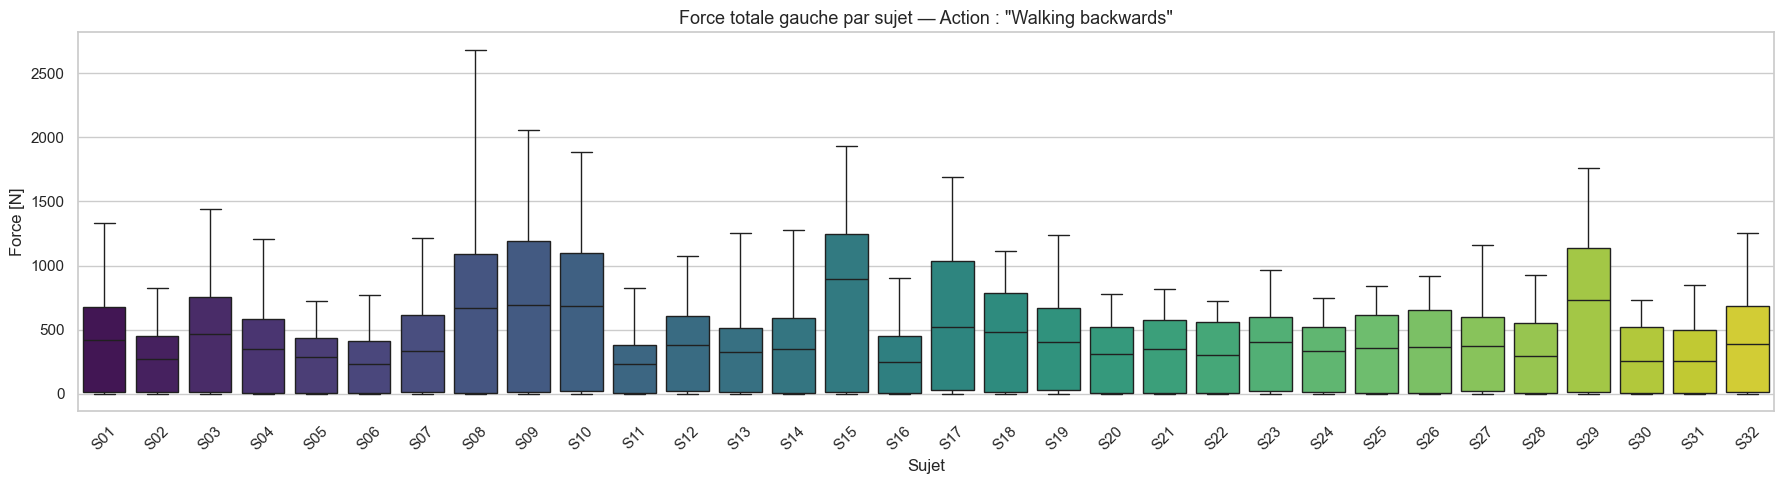


Force moyenne par sujet pour cette action :
         left total force[N]  right total force[N]
subject                                           
S01                    399.9                 376.1
S02                    266.9                 258.4
S03                    433.7                 383.2
S04                    329.3                 306.1
S05                    254.6                 194.8
S06                    230.5                 241.3
S07                    351.2                 330.4
S08                    619.8                 707.1
S09                    687.4                 686.2
S10                    635.7                 654.3
S11                    221.0                 218.5
S12                    350.0                 289.4
S13                    313.2                 273.0
S14                    339.2                 316.5
S15                    723.9                 576.8
S16                    252.8                 242.0
S17                    570.4         

In [16]:
# On choisit une action représentative pour comparer les sujets
# Modifie cette valeur si tu veux voir une autre action
ACTION_REFERENCE = 'Walking'  # Change si nécessaire

# Trouver une action contenant 'Walk' dans son nom (robuste aux variations)
available_actions = df_annotated['action_name'].unique()
walk_actions = [a for a in available_actions if 'walk' in a.lower() or 'Walk' in a]
if not walk_actions:
    walk_actions = list(available_actions[:3])
print(f'Actions de marche trouvées : {walk_actions}')
ACTION_REFERENCE = walk_actions[0]
print(f'→ On utilise : "{ACTION_REFERENCE}"')

# Filtrer sur cette action
df_walk = df_annotated[df_annotated['action_name'] == ACTION_REFERENCE]

# Boxplot par sujet
fig, ax = plt.subplots(figsize=(18, 5))
sns.boxplot(
    data=df_walk,
    x='subject',                  # Un groupe par sujet
    y='left total force[N]',
    ax=ax,
    palette='viridis'
)
ax.set_title(f'Force totale gauche par sujet — Action : "{ACTION_REFERENCE}"', fontsize=13)
ax.set_xlabel('Sujet')
ax.set_ylabel('Force [N]')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Moyenne par sujet (tableau)
print('\nForce moyenne par sujet pour cette action :')
print(df_walk.groupby('subject')[['left total force[N]', 'right total force[N]']].mean().round(1).to_string())

## 7. 🦶 Carte de pression plantaire (heatmap)

Les 16 capteurs par pied mesurent la pression à des endroits spécifiques de la plante du pied. On peut visualiser ces 16 valeurs sous forme d'une **carte de chaleur** (heatmap) pour voir quelles zones du pied sont les plus sollicitées.

### 📐 Layout anatomique des capteurs (grille 4×4)
Sans l'image officielle, on utilise un layout standard :
```
    [Orteils]
[ 1][ 2][ 3][ 4]
[ 5][ 6][ 7][ 8]
[ 9][10][11][12]
[13][14][15][16]
    [Talon]
```
> ⚠️ Ce layout est **approximatif**. Adapte-le si tu obtiens l'image `position_capteurs` du TD.

Affichage de la carte pour : "Standing in T-pose"


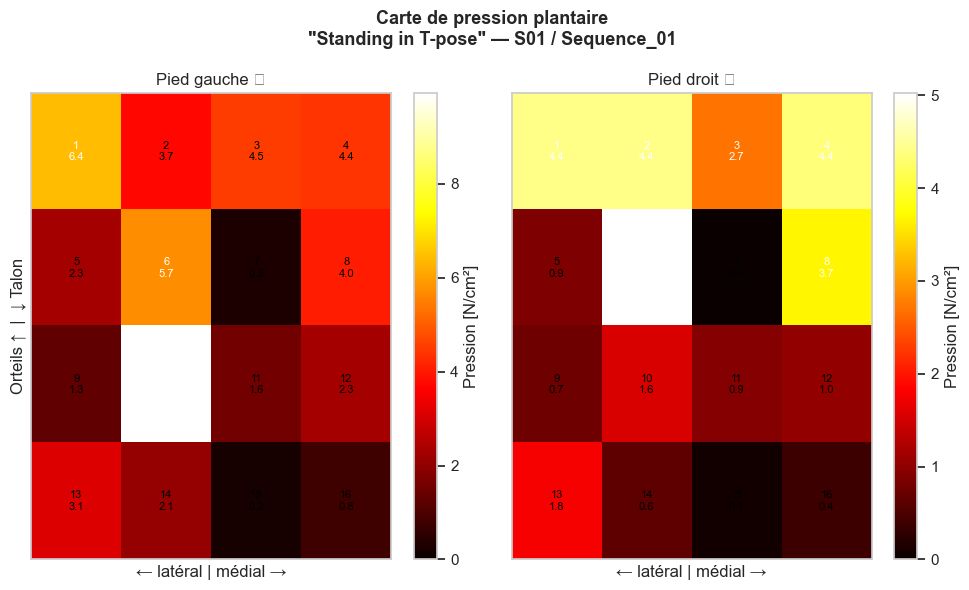

In [17]:
def get_pressure_map(df_subset, side='left'):
    """
    Calcule la pression moyenne des 16 capteurs d'un pied
    et la retourne sous forme d'une matrice 4×4.
    """
    # Noms des colonnes pour les 16 capteurs du pied choisi
    cols = [f'{side} pressure {i}[N/cm²]' for i in range(1, 17)]

    # On convertit en numérique (au cas où des valeurs seraient du texte)
    values = df_subset[cols].apply(pd.to_numeric, errors='coerce').mean().values  # 16 valeurs moyennes

    # On reshape en grille 4×4
    return values.reshape(4, 4)


def plot_pressure_maps(action_name, subject='S01', sequence='Sequence_01'):
    """
    Affiche les heatmaps gauche et droite pour une action et un sujet donnés.
    """
    # Filtrage : on veut une action précise pour un sujet et une séquence
    mask = (
        (insoles['action_name'] == action_name) &
        (insoles['subject']     == subject) &
        (insoles['sequence']    == sequence)
    )
    df_subset = insoles[mask]

    if df_subset.empty:
        print(f'⚠️  Aucune donnée pour : action="{action_name}", sujet={subject}, séquence={sequence}')
        return

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    for ax, side, label in zip(axes, ['left', 'right'], ['Pied gauche 🦵', 'Pied droit 🦵']):
        matrix = get_pressure_map(df_subset, side)

        # vmin/vmax : plage de couleurs fixée pour comparer gauche et droite
        im = ax.imshow(matrix, cmap='hot', vmin=0, aspect='auto')
        plt.colorbar(im, ax=ax, label='Pression [N/cm²]')

        # Annotations : afficher la valeur dans chaque case
        for i in range(4):
            for j in range(4):
                sensor_num = i * 4 + j + 1
                ax.text(j, i, f'{sensor_num}\n{matrix[i, j]:.1f}',
                        ha='center', va='center', fontsize=8,
                        color='white' if matrix[i, j] > matrix.max() * 0.5 else 'black')

        ax.set_title(f'{label}', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('← latéral | médial →')

    # Étiquettes anatomiques
    axes[0].set_ylabel('Orteils ↑  |  ↓ Talon')

    fig.suptitle(f'Carte de pression plantaire\n"{action_name}" — {subject} / {sequence}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ---- Utilisation ----
# On prend la première action disponible pour le sujet S01 / Sequence_01
first_action = classif[
    (classif['subject'] == 'S01') & (classif['sequence'] == 'Sequence_01')
].iloc[0]['Name']

print(f'Affichage de la carte pour : "{first_action}"')
plot_pressure_maps(first_action, subject='S01', sequence='Sequence_01')

# Tu peux changer l'action ci-dessous et réexécuter la cellule
# plot_pressure_maps('Walking', subject='S01', sequence='Sequence_01')

Comparaison des actions : ['Standing in T-pose', 'Standing on heels', 'Walking backwards', 'Climbing the stairs']


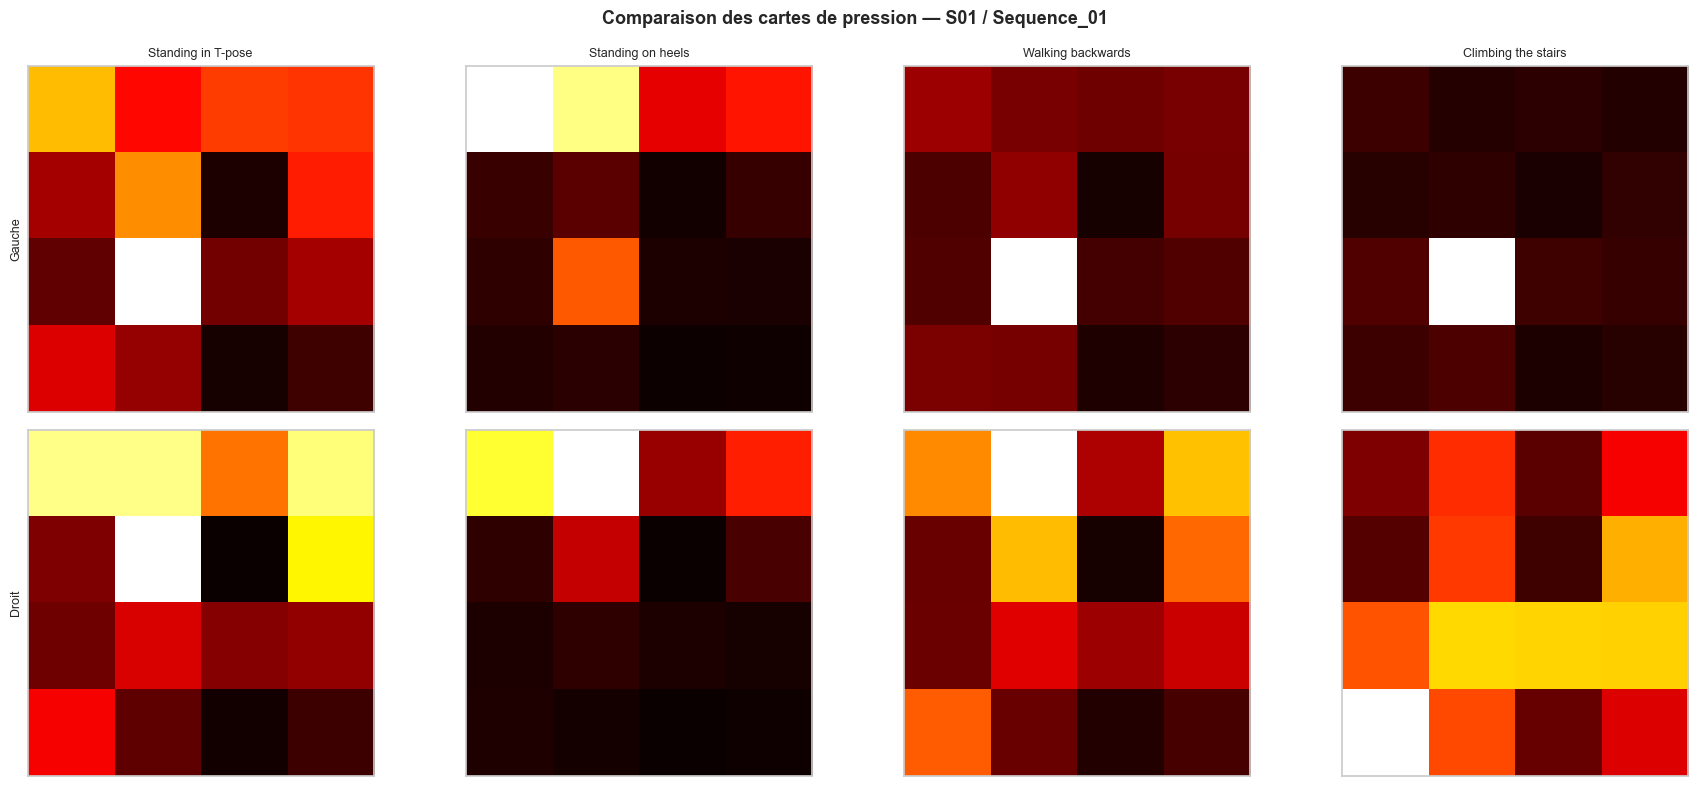

In [18]:
# Comparaison de 4 actions différentes sur la même figure
actions_to_compare = classif[
    (classif['subject'] == 'S01') & (classif['sequence'] == 'Sequence_01')
]['Name'].unique()[:4]  # On prend les 4 premières actions

print(f'Comparaison des actions : {list(actions_to_compare)}')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col_idx, action in enumerate(actions_to_compare):
    for row_idx, side in enumerate(['left', 'right']):
        ax = axes[row_idx, col_idx]

        mask = (
            (insoles['action_name'] == action) &
            (insoles['subject']     == 'S01') &
            (insoles['sequence']    == 'Sequence_01')
        )
        df_sub = insoles[mask]

        if df_sub.empty:
            ax.set_visible(False)
            continue

        matrix = get_pressure_map(df_sub, side)
        im = ax.imshow(matrix, cmap='hot', vmin=0)
        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(f'{action[:20]}', fontsize=9, wrap=True)
        if col_idx == 0:
            ax.set_ylabel('Gauche' if row_idx == 0 else 'Droit', fontsize=9)

fig.suptitle('Comparaison des cartes de pression — S01 / Sequence_01', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 📡 Courbes IMU — Accélérations et vitesses angulaires

Chaque semelle contient une **IMU** (Inertial Measurement Unit), qui comprend :
- Un **accéléromètre** : mesure l'accélération sur 3 axes (X, Y, Z) en **g** (1g ≈ 9.81 m/s²)
- Un **gyroscope** : mesure la vitesse de rotation sur 3 axes en **dps** (degrés par seconde)

Ces signaux permettent de détecter des mouvements (pas, chutes, sauts…).

On va tracer ces 6 signaux pour une fenêtre temporelle et **annoter les transitions entre actions**.

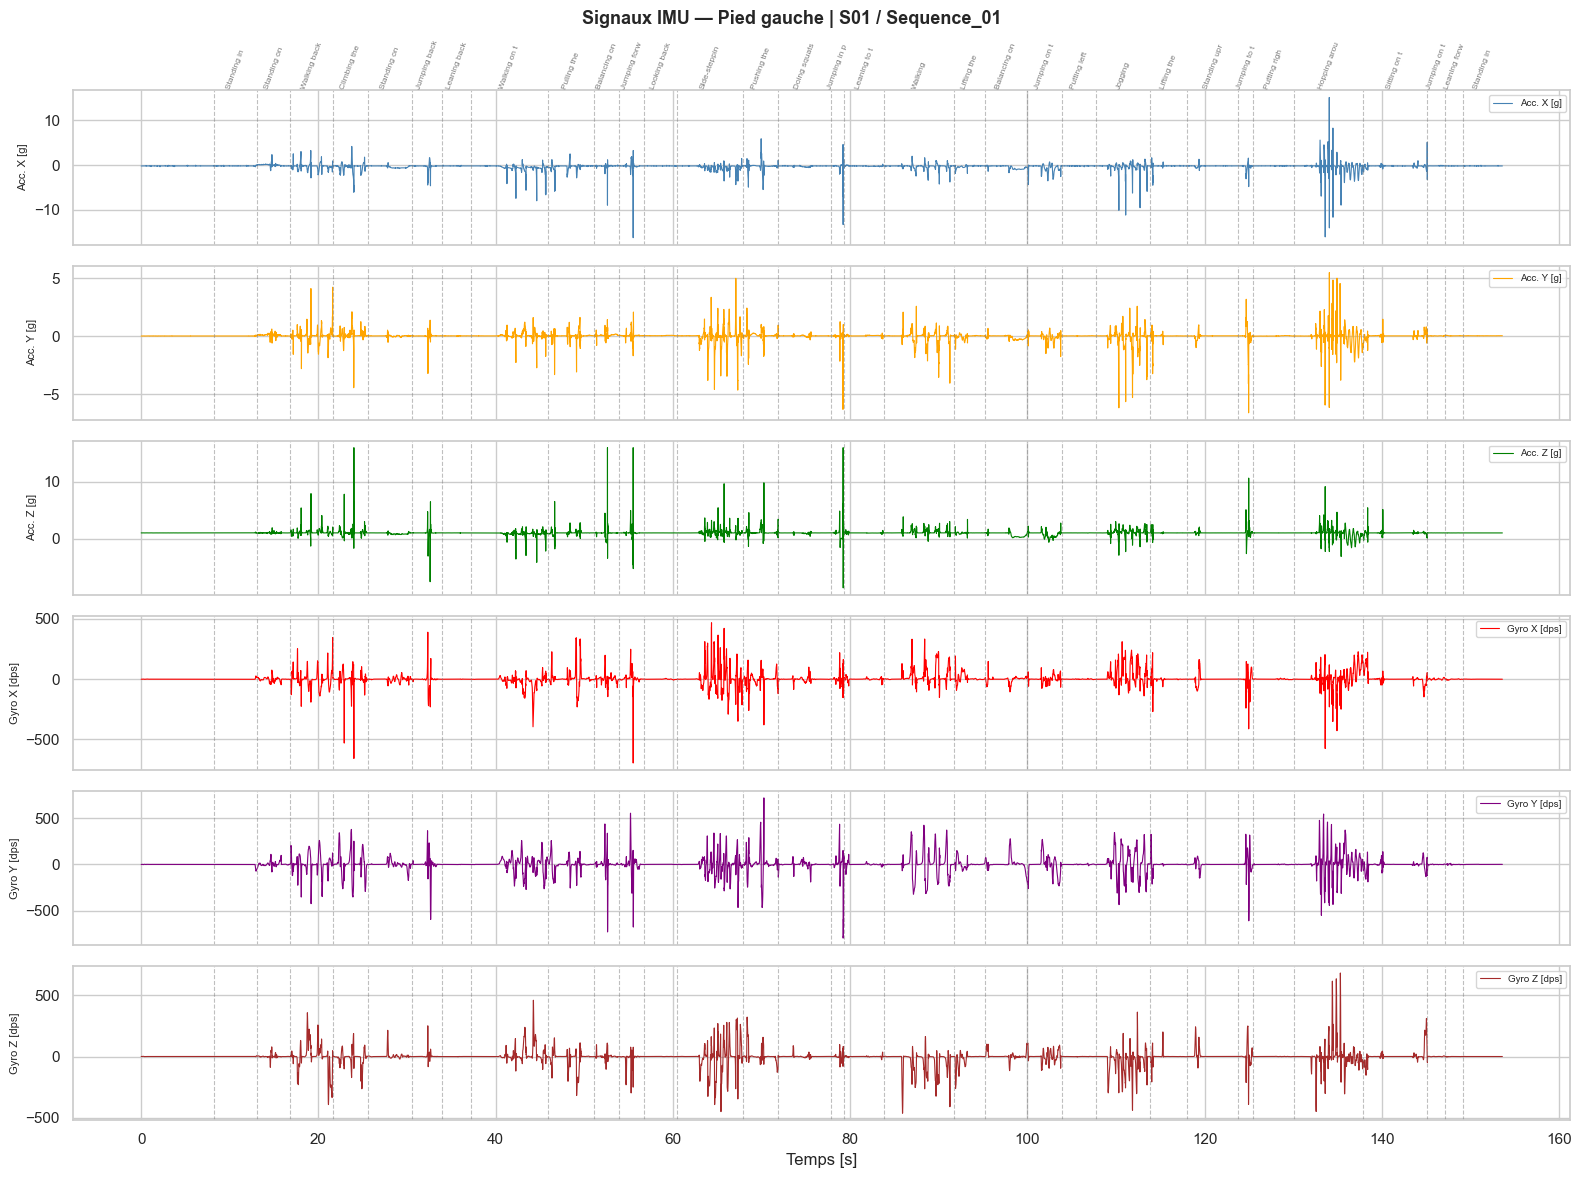

In [19]:
def plot_imu(subject='S01', sequence='Sequence_01', side='left', time_window=None):
    """
    Trace les 6 signaux IMU (acc X/Y/Z + angular X/Y/Z) pour un sujet/séquence.
    Ajoute des lignes verticales aux transitions entre actions.

    Args:
        subject     : ex. 'S01'
        sequence    : ex. 'Sequence_01'
        side        : 'left' ou 'right'
        time_window : tuple (t_start, t_end) pour zoomer ; None = toute la séquence
    """
    # Filtrer les données
    mask = (insoles['subject'] == subject) & (insoles['sequence'] == sequence)
    df_seq = insoles[mask].sort_values('Time')

    if time_window:
        df_seq = df_seq[(df_seq['Time'] >= time_window[0]) & (df_seq['Time'] <= time_window[1])]

    # Annotations pour cette séquence
    annots = classif[(classif['subject'] == subject) & (classif['sequence'] == sequence)]

    # Signaux à tracer
    signals = [
        (f'{side} acceleration X[g]',  'Acc. X [g]',   'steelblue'),
        (f'{side} acceleration Y[g]',  'Acc. Y [g]',   'orange'),
        (f'{side} acceleration Z[g]',  'Acc. Z [g]',   'green'),
        (f'{side} angular X[dps]',     'Gyro X [dps]', 'red'),
        (f'{side} angular Y[dps]',     'Gyro Y [dps]', 'purple'),
        (f'{side} angular Z[dps]',     'Gyro Z [dps]', 'brown'),
    ]

    fig, axes = plt.subplots(6, 1, figsize=(16, 12), sharex=True)  # sharex : même axe X

    for ax, (col, ylabel, color) in zip(axes, signals):
        if col in df_seq.columns:
            y = pd.to_numeric(df_seq[col], errors='coerce')
            ax.plot(df_seq['Time'], y, color=color, linewidth=0.8, label=ylabel)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.legend(loc='upper right', fontsize=7)

        # Lignes verticales aux transitions d'action
        for _, row in annots.iterrows():
            ax.axvline(x=row['Timestamp Start'], color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

    # Étiquettes des actions en haut
    ax_top = axes[0]
    for _, row in annots.iterrows():
        t_mid = (row['Timestamp Start'] + row['Timestamp End']) / 2
        t_visible = df_seq['Time']
        if not t_visible.empty and t_mid >= t_visible.min() and t_mid <= t_visible.max():
            ax_top.text(t_mid, ax_top.get_ylim()[1], row['Name'][:12],
                        rotation=70, fontsize=6, ha='center', va='bottom', color='gray')

    axes[-1].set_xlabel('Temps [s]')
    side_label = 'gauche' if side == 'left' else 'droit'
    fig.suptitle(f'Signaux IMU — Pied {side_label} | {subject} / {sequence}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Trace toute la séquence 01 du sujet S01
plot_imu(subject='S01', sequence='Sequence_01', side='left')

In [ ]:
# Zoom sur une fenêtre temporelle pour mieux voir un mouvement
# On prend la première action du sujet S01 / Sequence_01
first = classif[(classif['subject'] == 'S01') & (classif['sequence'] == 'Sequence_01')].iloc[0]
t_start = first['Timestamp Start']
t_end   = first['Timestamp End']
print(f'Zoom sur : "{first["Name"]}" ({t_start:.1f}s → {t_end:.1f}s)')

plot_imu(subject='S01', sequence='Sequence_01', side='left', time_window=(t_start, t_end))

## 9. 🎯 Trajectoire du Centre de Pression (COP)

Le **Centre de Pression** (COP) est le point d'application de la résultante des forces exercées sur le sol. Il se déplace dans le plan horizontal (X, Y) en fonction du mouvement.

Les valeurs sont normalisées entre **-0.5 et +0.5** :
- `X` : direction médio-latérale (de l'intérieur vers l'extérieur du pied)
- `Y` : direction antéro-postérieure (du talon vers les orteils)

La trajectoire du COP est très différente selon l'action : debout = faibles oscillations, marche = trajectoire ondulante, saut = pic vers l'avant.

In [ ]:
def plot_cop(action_name, subject='S01', sequence='Sequence_01'):
    """
    Trace la trajectoire du Centre de Pression (COP) gauche et droit
    pour une action donnée.
    """
    mask = (
        (insoles['action_name'] == action_name) &
        (insoles['subject']     == subject) &
        (insoles['sequence']    == sequence)
    )
    df_sub = insoles[mask].sort_values('Time')

    if df_sub.empty:
        print(f'⚠️  Aucune donnée pour "{action_name}"')
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, side, label in zip(axes, ['left', 'right'], ['Pied gauche', 'Pied droit']):
        col_x = f'{side} center of pressure X[-0.5...+0.5]'
        col_y = f'{side} center of pressure Y[-0.5...+0.5]'

        x = pd.to_numeric(df_sub[col_x], errors='coerce')
        y = pd.to_numeric(df_sub[col_y], errors='coerce')

        # Tracer la trajectoire avec un dégradé de couleur selon le temps
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        from matplotlib.collections import LineCollection
        from matplotlib.cm import viridis

        t = np.linspace(0, 1, len(segments))
        lc = LineCollection(segments, array=t, cmap='viridis', linewidth=1.5, alpha=0.8)
        ax.add_collection(lc)

        # Points de départ (vert) et d'arrivée (rouge)
        if len(x.dropna()) > 0:
            ax.scatter(x.dropna().iloc[0],  y.dropna().iloc[0],  color='green', s=80, zorder=5, label='Début')
            ax.scatter(x.dropna().iloc[-1], y.dropna().iloc[-1], color='red',   s=80, zorder=5, label='Fin')

        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(-0.6, 0.6)
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
        ax.set_xlabel('X médio-latéral [-0.5, +0.5]')
        ax.set_ylabel('Y antéro-postérieur [-0.5, +0.5]')
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=8)
        ax.set_aspect('equal')

        # Colorbar pour indiquer la progression temporelle
        sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, 1))
        plt.colorbar(sm, ax=ax, label='Progression temporelle →')

    fig.suptitle(f'Trajectoire du Centre de Pression — "{action_name}"\n{subject} / {sequence}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# On trace le COP pour la première action disponible
print(f'COP pour : "{first_action}"')
plot_cop(first_action, subject='S01', sequence='Sequence_01')

In [ ]:
# Comparaison du COP entre plusieurs actions sur le même graphique
actions_cop = classif[
    (classif['subject'] == 'S01') & (classif['sequence'] == 'Sequence_01')
]['Name'].unique()[:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(actions_cop)))

for side_idx, (side, label) in enumerate([('left', 'Pied gauche'), ('right', 'Pied droit')]):
    ax = axes[side_idx]
    col_x = f'{side} center of pressure X[-0.5...+0.5]'
    col_y = f'{side} center of pressure Y[-0.5...+0.5]'

    for action, color in zip(actions_cop, colors):
        mask = (
            (insoles['action_name'] == action) &
            (insoles['subject']     == 'S01') &
            (insoles['sequence']    == 'Sequence_01')
        )
        df_sub = insoles[mask]
        if df_sub.empty:
            continue
        x = pd.to_numeric(df_sub[col_x], errors='coerce').dropna()
        y = pd.to_numeric(df_sub[col_y], errors='coerce').dropna()
        ax.plot(x.values, y.values, color=color, linewidth=1.2, alpha=0.8, label=action[:20])

    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('X médio-latéral')
    ax.set_ylabel('Y antéro-postérieur')
    ax.set_title(label)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal')

fig.suptitle('Comparaison des trajectoires COP — S01 / Sequence_01', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. 📝 Observations et conclusions

Cette section est à remplir **avec tes propres observations** après avoir exécuté toutes les cellules ci-dessus.

---

### 🔎 Observations sur les données

*(Remplis ce tableau après avoir exécuté les cellules)*

| Aspect | Observation |
|---|---|
| Valeurs manquantes | ??? |
| Action avec force maximale | ??? |
| Action avec force minimale | ??? |
| Sujet avec la plus grande variabilité | ??? |
| Zone du pied la plus sollicitée | ??? |
| Action avec COP le plus étendu | ??? |

---

### 🔮 Pistes pour le prochain TD — Entraînement d'un modèle

Avant d'entraîner un modèle de Machine Learning, plusieurs étapes de préparation sont nécessaires :

#### 1. Normalisation
- Les capteurs de pression ont des valeurs en `N/cm²`, les IMU en `g` et `dps` : les plages sont très différentes.
- **Solution :** Z-score par colonne et par sujet → `(x - mean) / std`. Ça ramène tout à une moyenne de 0 et un écart-type de 1.

#### 2. Fenêtrage glissant (sliding window)
- Les modèles classiques de reconnaissance d'actions prennent en entrée des **fenêtres de temps fixe** (ex. 1 seconde = 100 échantillons à 100 Hz).
- **Solution :** Découper chaque séquence en fenêtres qui se chevauchent (stride = 50, window = 100).

#### 3. Extraction de features
- Plutôt que de donner 100 × 50 valeurs brutes à un modèle, on peut résumer chaque fenêtre par des **caractéristiques** :
  - **RMS** (Root Mean Square) : énergie du signal
  - **Maximum**, **écart-type**
  - **Entropie** : mesure de l'irrégularité
  - **Intégrale** (aire sous la courbe) : pour la force

#### 4. Nettoyage
- Traiter les valeurs manquantes (interpolation linéaire ou suppression)
- Supprimer les fenêtres avec trop de données manquantes
- Vérifier les labels : toutes les fenêtres ont-elles une classe ?

---

### ✅ Récapitulatif de ce qu'on a fait

| Tâche | Fait ? |
|---|---|
| Chargement de insoles.csv et classif.csv | ✅ |
| Exploration des types, stats, valeurs manquantes | ✅ |
| Alignement signaux ↔ annotations | ✅ |
| Comparaison inter-classes (boxplot force) | ✅ |
| Comparaison inter-sujets | ✅ |
| Carte de pression plantaire (heatmap) | ✅ |
| Courbes IMU avec transitions annotées | ✅ |
| Trajectoire du Centre de Pression | ✅ |
| Conclusions et pistes pour le prochain TD | ✅ |